<a href="https://colab.research.google.com/github/JakubPac/kurs_data_science/blob/main/pierwsza_siec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [3]:
import keras # do tf niepotrzebne

In [4]:
import matplotlib.pyplot as plt

In [5]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [6]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [8]:
(X_train, y_train), (X_test, y_test) = load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [9]:
print(X_test[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 19

In [10]:
# normalizacja
X_train = X_train / 255
X_test = X_test / 255

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

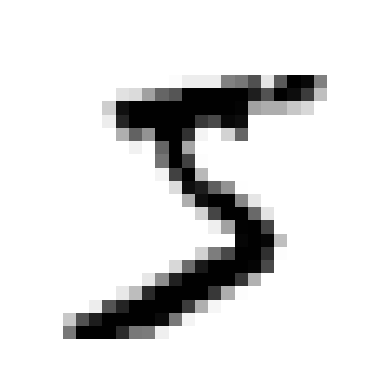

In [11]:
plt.imshow(X_train[0], cmap = 'gray_r')
plt.axis('off')

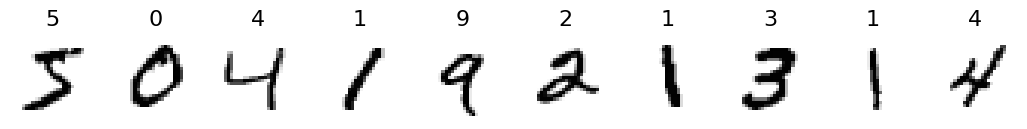

In [14]:
plt.figure(figsize = (13,13))

for i in range(1,11):
    plt.subplot(1, 10, i)
    plt.axis('off')
    plt.imshow(X_train[i-1], cmap = 'gray_r')
    plt.title(y_train[i-1], color = 'black', fontsize = 16)
plt.show()

budowa sieci

In [16]:
model = Sequential()
model.add(Flatten(input_shape = (28,28)))
model.add(Dense(units = 128, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 10, activation = 'softmax'))

model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu

In [17]:
history = model.fit(X_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8563 - loss: 0.4900
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9549 - loss: 0.1502
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9689 - loss: 0.1034
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9731 - loss: 0.0853
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9783 - loss: 0.0726


Ocena modelu

In [18]:
model.evaluate(X_test, y_test, verbose = 2)

313/313 - 1s - 2ms/step - accuracy: 0.9770 - loss: 0.0701


[0.07010219246149063, 0.9769999980926514]

In [23]:
metrics = pd.DataFrame(history.history)
metrics

,accuracy,loss
0,0.913483,0.296215
1,0.957417,0.140482
2,0.968467,0.106065
3,0.972450,0.087560
4,0.977083,0.073987


In [25]:
fig = make_subplots(rows = 2, cols = 1)
fig.add_trace(go.Scatter(y = metrics['loss'], name = 'loss'), row = 1, col =1)
fig.add_trace(go.Scatter(y = metrics['accuracy'], name = 'accuracy'), row = 2, col =1)
fig.update_layout(width = 800, height = 400)

Predykcja na podstawie modelu

In [27]:
model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[1.9162384e-07, 3.6079331e-10, 2.5390843e-06, ..., 9.9994081e-01,
        1.8088956e-07, 1.4834980e-05],
       [6.0476674e-10, 3.1607880e-04, 9.9967849e-01, ..., 1.4648047e-12,
        2.0661828e-06, 3.2131351e-14],
       [1.6579831e-08, 9.9959403e-01, 5.4193573e-05, ..., 2.6099765e-04,
        7.7940567e-05, 4.7599011e-07],
       ...,
       [1.2604909e-10, 2.1936000e-10, 8.6328021e-11, ..., 2.4385556e-06,
        1.9147261e-05, 8.5105632e-05],
       [3.1919227e-09, 2.0069949e-08, 1.2319339e-10, ..., 2.8320228e-08,
        6.1421667e-04, 7.4753999e-09],
       [4.3449706e-09, 7.3598861e-12, 2.0508155e-08, ..., 2.6423513e-11,
        8.1014342e-09, 6.7447981e-09]], dtype=float32)

In [32]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [34]:
pred = pd.concat([pd.DataFrame(y_test, columns = ['y_test']), pd.DataFrame(y_pred, columns = ['y_pred'])], axis = 1)

In [35]:
pred.head(10)

,y_test,y_pred
0,7,7
1,2,2
2,1,1
3,0,0
4,4,4
5,1,1
6,4,4
7,9,9
8,5,5
9,9,9


In [36]:
misclasified = pred[y_pred != y_test]
misclasified

,y_test,y_pred
247,4,2
321,2,7
340,5,3
381,3,7
445,6,0
...,...,...
9839,2,7
9922,4,9
9941,5,6
9944,3,5


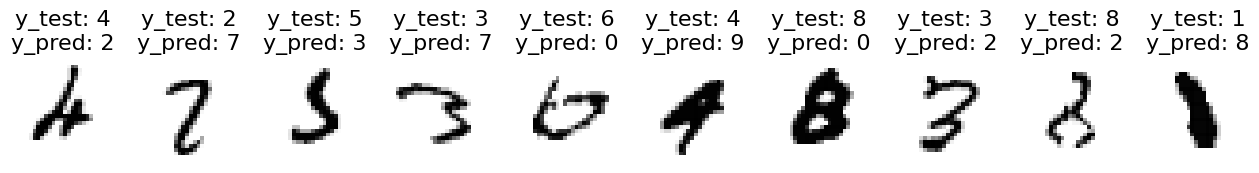

In [39]:
plt.figure(figsize = (16,16))

for i, j in zip(range(1,11), misclasified.index[:10]):
    plt.subplot(1, 10, i)
    plt.axis('off')
    plt.imshow(X_test[j], cmap = 'gray_r')
    plt.title(f'y_test: {y_test[j]}\ny_pred: {y_pred[j]}', color = 'black', fontsize = 16)
plt.show()